<a href="https://colab.research.google.com/github/sheylaxiomaramo/Telecom-X---Part-1/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [27]:
import pandas as pd

# Cargar el archivo JSON
ruta_archivo = "TelecomX_Data.json"
df = pd.read_json(ruta_archivo)

# Aplanar columnas anidadas
df_customer = pd.json_normalize(df['customer'])
df_phone = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account = pd.json_normalize(df['account'])

# Unir todo en un solo DataFrame
df_final = pd.concat(
    [df[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account],
    axis=1
)

# Revisar estructura final
print(df_final.head())
print(df_final.info())

   customerID Churn  gender  SeniorCitizen Partner Dependents  tenure  \
0  0002-ORFBO    No  Female              0     Yes        Yes       9   
1  0003-MKNFE    No    Male              0      No         No       9   
2  0004-TLHLJ   Yes    Male              0      No         No       4   
3  0011-IGKFF   Yes    Male              1     Yes         No      13   
4  0013-EXCHZ   Yes  Female              1     Yes         No       3   

  PhoneService MultipleLines InternetService  ... OnlineBackup  \
0          Yes            No             DSL  ...          Yes   
1          Yes           Yes             DSL  ...           No   
2          Yes            No     Fiber optic  ...           No   
3          Yes            No     Fiber optic  ...          Yes   
4          Yes            No     Fiber optic  ...           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No         Yes         Yes              No        One year   
1       

#🔧 Transformación

**Explorar columnas y tipos de datos**

In [19]:
# Ver columnas y tipos de datos
print(df_final.info())

# Ver las primeras filas para entender el contenido
print(df_final.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 



*   **Comprobación de incoherencias en los datos**

In [36]:
# Conteo de valores nulos por columna
valores_nulos = df_final.isnull().sum()

# Porcentaje de valores nulos
porcentaje_nulos = (df_final.isnull().mean() * 100).round(2)

print(pd.DataFrame({
    "Valores Nulos": valores_nulos,
    "Porcentaje (%)": porcentaje_nulos
}))


                  Valores Nulos  Porcentaje (%)
customerID                    0            0.00
Churn                         0            0.00
gender                        0            0.00
SeniorCitizen                 0            0.00
Partner                       0            0.00
Dependents                    0            0.00
tenure                        0            0.00
PhoneService                  0            0.00
MultipleLines                 0            0.00
InternetService               0            0.00
OnlineSecurity                0            0.00
OnlineBackup                  0            0.00
DeviceProtection              0            0.00
TechSupport                   0            0.00
StreamingTV                   0            0.00
StreamingMovies               0            0.00
Contract                      0            0.00
PaperlessBilling              0            0.00
PaymentMethod                 0            0.00
Charges.Monthly               0         



*   **Errores de formato**



In [37]:
# Convertir a numérico y ver si hay problemas
df_final['Charges.Monthly'] = pd.to_numeric(df_final['Charges.Monthly'], errors='coerce')
df_final['Charges.Total'] = pd.to_numeric(df_final['Charges.Total'], errors='coerce')
df_final['tenure'] = pd.to_numeric(df_final['tenure'], errors='coerce')

# Ver si aparecieron nulos tras conversión (indicando datos mal formateados)
print(df_final[['Charges.Monthly', 'Charges.Total', 'tenure']].isnull().sum())

Charges.Monthly     0
Charges.Total      11
tenure              0
dtype: int64




*   **Duplicados**


In [38]:
# Filas duplicadas completas
duplicados = df_final.duplicated().sum()
print(f"Duplicados encontrados: {duplicados}")

# Si hay duplicados, se eliminan con:
# df_final = df_final.drop_duplicates()


Duplicados encontrados: 0



* **Inconsistencias en categorías**


In [39]:
# Ejemplo: revisar categorías únicas de variables categóricas clave
categoricas = ['gender', 'Partner', 'Dependents', 'PhoneService', 'InternetService',
               'OnlineSecurity', 'TechSupport', 'Contract', 'PaymentMethod']

for col in categoricas:
    print(f"\n{col} -> {df_final[col].unique()}")



gender -> ['Female' 'Male']

Partner -> ['Yes' 'No']

Dependents -> ['Yes' 'No']

PhoneService -> ['Yes' 'No']

InternetService -> ['DSL' 'Fiber optic' 'No']

OnlineSecurity -> ['No' 'Yes' 'No internet service']

TechSupport -> ['Yes' 'No' 'No internet service']

Contract -> ['One year' 'Month-to-month' 'Two year']

PaymentMethod -> ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']




*  **Resumen del estado de los datos**



In [40]:
resumen = {
    "Total Filas": len(df_final),
    "Valores Nulos Totales": df_final.isnull().sum().sum(),
    "Duplicados": df_final.duplicated().sum()
}
print(resumen)


{'Total Filas': 7267, 'Valores Nulos Totales': np.int64(11), 'Duplicados': np.int64(0)}


**Columna de cuentas diarias**

In [42]:
# Crear columna de cuentas diarias
df_final['Cuentas_Diarias'] = df_final['Charges.Monthly'] / 30

# Verificar el resultado
print(df_final[['Charges.Monthly', 'Cuentas_Diarias']].head())

   Charges.Monthly  Cuentas_Diarias
0             65.6         2.186667
1             59.9         1.996667
2             73.9         2.463333
3             98.0         3.266667
4             83.9         2.796667


**La estandarización y transformación de datos**

In [43]:
# Lista de columnas con Sí/No
cols_binarias = [
    'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling'
]

# Convertir
for col in cols_binarias:
    df_final[col] = df_final[col].map({'Yes': 1, 'No': 0, 'Sí': 1, 'No': 0})


In [44]:
df_final['Churn'] = df_final['Churn'].map({'Yes': 1, 'No': 0})


In [45]:
df_final.columns = df_final.columns.str.strip().str.lower().str.replace(' ', '_')


In [46]:
df_final.rename(columns={
    'customerid': 'id_cliente',
    'gender': 'genero',
    'seniorcitizen': 'adulto_mayor',
    'monthlycharges': 'cargos_mensuales',
    'totalcharges': 'cargos_totales',
    'tenure': 'meses_permanencia',
    'cuentas_diarias': 'cargos_diarios'
}, inplace=True)


In [47]:
print(df_final.head())
print(df_final.info())


   id_cliente  churn  genero  adulto_mayor  partner  dependents  \
0  0002-ORFBO    0.0  Female             0        1           1   
1  0003-MKNFE    0.0    Male             0        0           0   
2  0004-TLHLJ    1.0    Male             0        0           0   
3  0011-IGKFF    1.0    Male             1        1           0   
4  0013-EXCHZ    1.0  Female             1        1           0   

   meses_permanencia  phoneservice  multiplelines internetservice  ...  \
0                  9             1            0.0             DSL  ...   
1                  9             1            1.0             DSL  ...   
2                  4             1            0.0     Fiber optic  ...   
3                 13             1            0.0     Fiber optic  ...   
4                  3             1            0.0     Fiber optic  ...   

   deviceprotection  techsupport  streamingtv  streamingmovies  \
0               0.0          1.0          1.0              0.0   
1               0.0 

#📊 Carga y análisis

# **Análisis Descriptivo**

In [49]:
import numpy as np
# Estadísticas generales
stats_numericas = df_final.describe().T

# Agregar mediana
# Select only numeric columns before calculating the median
stats_numericas['mediana'] = df_final.select_dtypes(include=np.number).median()

# Redondear para mejor lectura
stats_numericas = stats_numericas.round(2)

print(stats_numericas)

                    count     mean      std    min     25%      50%      75%  \
churn              7043.0     0.27     0.44   0.00    0.00     0.00     1.00   
adulto_mayor       7267.0     0.16     0.37   0.00    0.00     0.00     0.00   
partner            7267.0     0.48     0.50   0.00    0.00     0.00     1.00   
dependents         7267.0     0.30     0.46   0.00    0.00     0.00     1.00   
meses_permanencia  7267.0    32.35    24.57   0.00    9.00    29.00    55.00   
phoneservice       7267.0     0.90     0.30   0.00    1.00     1.00     1.00   
multiplelines      6560.0     0.47     0.50   0.00    0.00     0.00     1.00   
onlinesecurity     5686.0     0.37     0.48   0.00    0.00     0.00     1.00   
onlinebackup       5686.0     0.44     0.50   0.00    0.00     0.00     1.00   
deviceprotection   5686.0     0.44     0.50   0.00    0.00     0.00     1.00   
techsupport        5686.0     0.37     0.48   0.00    0.00     0.00     1.00   
streamingtv        5686.0     0.49     0

In [50]:
churn_counts = df_final['churn'].value_counts()
churn_percent = df_final['churn'].value_counts(normalize=True) * 100

print("Distribución Churn (conteo):\n", churn_counts)
print("\nDistribución Churn (%):\n", churn_percent.round(2))


Distribución Churn (conteo):
 churn
0.0    5174
1.0    1869
Name: count, dtype: int64

Distribución Churn (%):
 churn
0.0    73.46
1.0    26.54
Name: proportion, dtype: float64


In [51]:
# Revisar frecuencia de categorías principales
categoricas = ['genero', 'internetservice', 'contract', 'paymentmethod']

for col in categoricas:
    print(f"\n{col}:\n", df_final[col].value_counts())



genero:
 genero
Male      3675
Female    3592
Name: count, dtype: int64

internetservice:
 internetservice
Fiber optic    3198
DSL            2488
No             1581
Name: count, dtype: int64

contract:
 contract
Month-to-month    4005
Two year          1743
One year          1519
Name: count, dtype: int64

paymentmethod:
 paymentmethod
Electronic check             2445
Mailed check                 1665
Bank transfer (automatic)    1589
Credit card (automatic)      1568
Name: count, dtype: int64


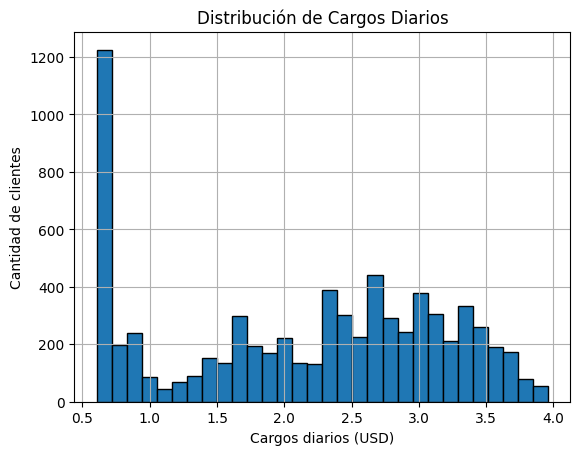

In [52]:
import matplotlib.pyplot as plt

df_final['cargos_diarios'].hist(bins=30, edgecolor='black')
plt.title('Distribución de Cargos Diarios')
plt.xlabel('Cargos diarios (USD)')
plt.ylabel('Cantidad de clientes')
plt.show()


# **Distribución de evasión**

#📄Informe final

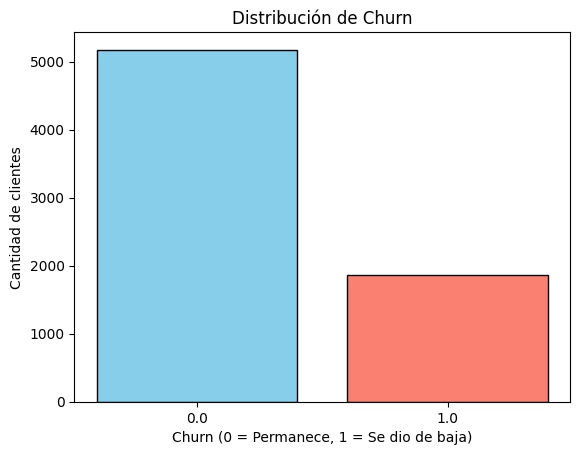

In [53]:
import matplotlib.pyplot as plt

# Conteo de clientes por estado de evasión
churn_counts = df_final['churn'].value_counts()

# Gráfico de barras
plt.bar(churn_counts.index.astype(str), churn_counts.values, color=['skyblue', 'salmon'], edgecolor='black')
plt.title('Distribución de Churn')
plt.xlabel('Churn (0 = Permanece, 1 = Se dio de baja)')
plt.ylabel('Cantidad de clientes')
plt.show()


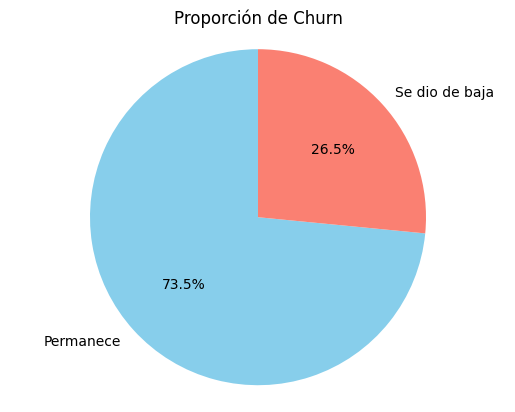

In [54]:
# Porcentaje de clientes
churn_percent = churn_counts / churn_counts.sum()

# Gráfico de pastel
plt.pie(churn_percent, labels=['Permanece', 'Se dio de baja'], autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=90)
plt.title('Proporción de Churn')
plt.axis('equal')  # Para que el gráfico sea circular
plt.show()


# **Recuento de evasión por variables categóricas**

In [55]:
# Lista de variables categóricas a analizar
categoricas = ['genero', 'internetservice', 'contract', 'paymentmethod']

for col in categoricas:
    print(f"\n--- {col.upper()} ---")

    # Conteo cruzado
    conteo = pd.crosstab(df_final[col], df_final['churn'])

    # Porcentaje sobre total de la categoría
    porcentaje = pd.crosstab(df_final[col], df_final['churn'], normalize='index') * 100

    print("Conteo:\n", conteo)
    print("\nPorcentaje:\n", porcentaje.round(2))



--- GENERO ---
Conteo:
 churn    0.0  1.0
genero           
Female  2549  939
Male    2625  930

Porcentaje:
 churn     0.0    1.0
genero              
Female  73.08  26.92
Male    73.84  26.16

--- INTERNETSERVICE ---
Conteo:
 churn             0.0   1.0
internetservice            
DSL              1962   459
Fiber optic      1799  1297
No               1413   113

Porcentaje:
 churn              0.0    1.0
internetservice              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40

--- CONTRACT ---
Conteo:
 churn            0.0   1.0
contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48

Porcentaje:
 churn             0.0    1.0
contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83

--- PAYMENTMETHOD ---
Conteo:
 churn                       0.0   1.0
paymentmethod                        
Bank transfer (automatic)  1286   258


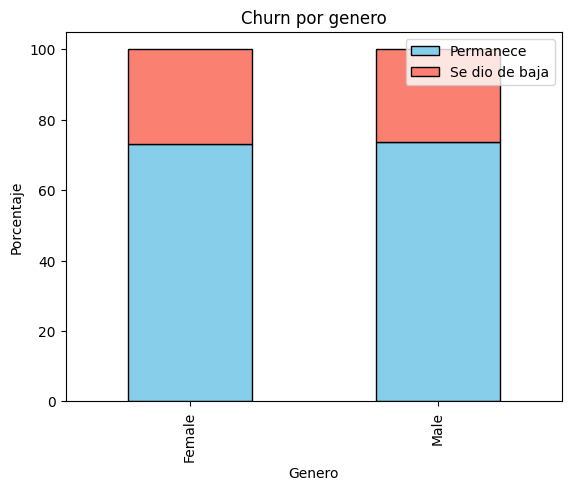

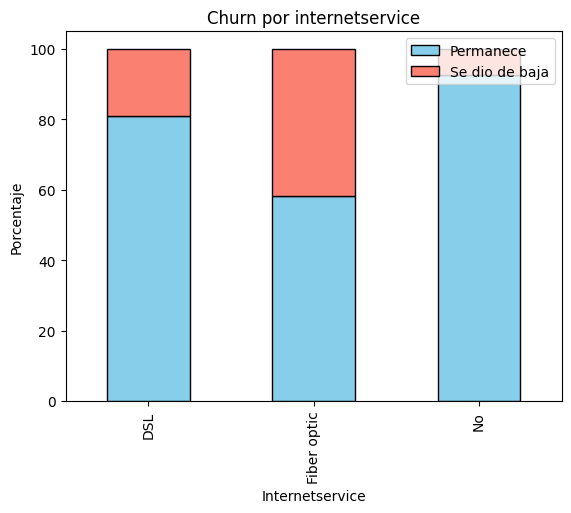

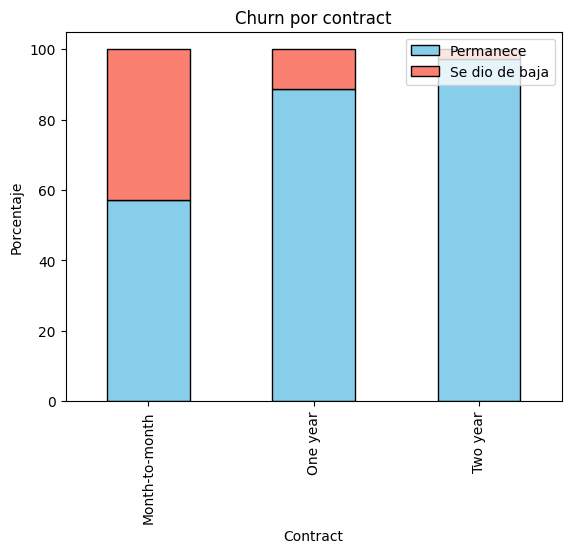

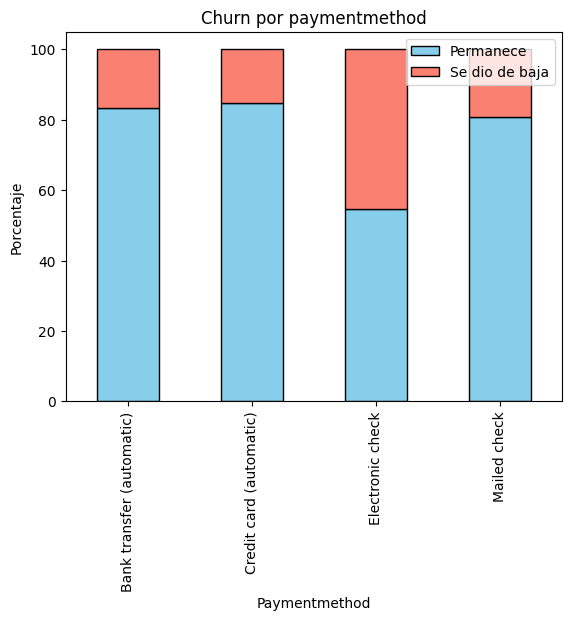

In [56]:
import matplotlib.pyplot as plt

def graficar_churn_por_categoria(col):
    # Calcula proporciones
    prop = pd.crosstab(df_final[col], df_final['churn'], normalize='index') * 100

    # Gráfico
    prop.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'], edgecolor='black')
    plt.title(f'Churn por {col}')
    plt.ylabel('Porcentaje')
    plt.xlabel(col.capitalize())
    plt.legend(['Permanece', 'Se dio de baja'], loc='upper right')
    plt.show()

# Graficar para cada categoría
for col in categoricas:
    graficar_churn_por_categoria(col)


**Interpretación esperada**
*   Tipo de contrato (contract): clientes con contrato mes a mes suelen tener más evasión que los de contratos anuales.
*   Método de pago (paymentmethod): pago automático con tarjeta o débito suele estar asociado a menor evasión.
*   Tipo de internet (internetservice): usuarios de fibra óptica en algunos datasets muestran mayor churn que DSL.
*   Género (genero): normalmente no hay una diferencia muy marcada, pero conviene confirmarlo.


**Conteo de evasión por variables numéricas**

In [58]:
# Agrupar por churn y calcular estadísticas
numericas = ['charges.total', 'meses_permanencia', 'charges.monthly']

resumen_por_churn = df_final.groupby('churn')[numericas].agg(['mean', 'median', 'std', 'min', 'max']).round(2)

print(resumen_por_churn)

      charges.total                                   meses_permanencia  \
               mean   median      std    min      max              mean   
churn                                                                     
0.0         2555.34  1683.60  2329.46  18.80  8672.45             37.57   
1.0         1531.80   703.55  1890.82  18.85  8684.80             17.98   

                            charges.monthly                               
      median    std min max            mean median    std    min     max  
churn                                                                     
0.0     38.0  24.11   0  72           61.27  64.43  31.09  18.25  118.75  
1.0     10.0  19.53   1  72           74.44  79.65  24.67  18.85  118.35  


<Figure size 600x400 with 0 Axes>

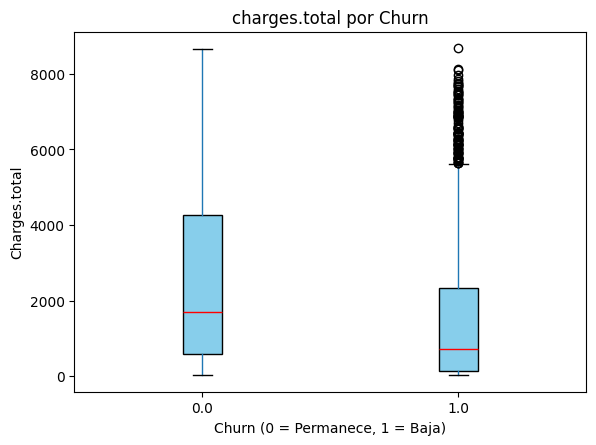

<Figure size 600x400 with 0 Axes>

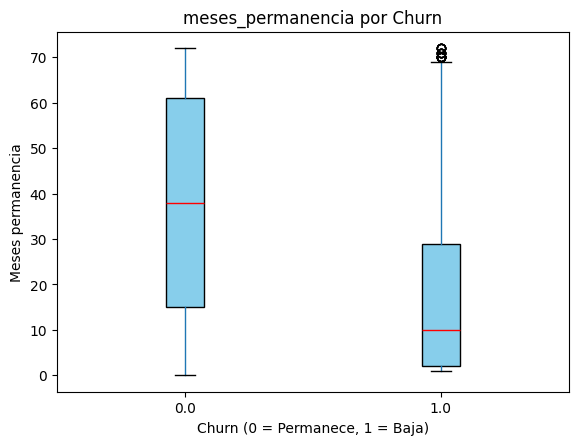

<Figure size 600x400 with 0 Axes>

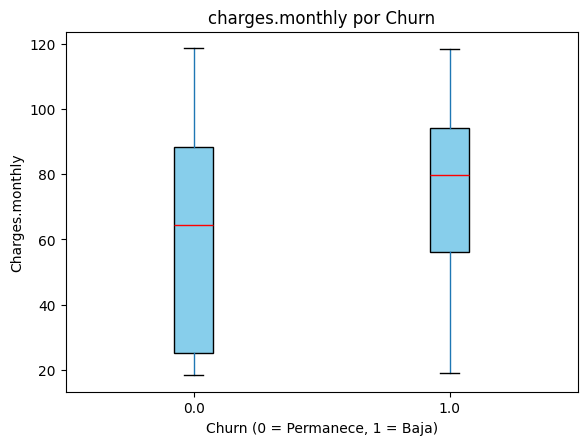

In [59]:
import matplotlib.pyplot as plt

def boxplot_por_churn(col):
    plt.figure(figsize=(6,4))
    df_final.boxplot(column=col, by='churn', grid=False,
                     patch_artist=True,
                     boxprops=dict(facecolor='skyblue', color='black'),
                     medianprops=dict(color='red'))
    plt.title(f'{col} por Churn')
    plt.suptitle('')
    plt.xlabel('Churn (0 = Permanece, 1 = Baja)')
    plt.ylabel(col.replace('_', ' ').capitalize())
    plt.show()

for col in numericas:
    boxplot_por_churn(col)


* Clientes con tenure bajo (pocos meses de permanencia) suelen tener mayor churn.

* Cargos mensuales altos pueden estar asociados a más bajas.

* El total gastado puede ser bajo en churn alto, porque cancelaron antes.

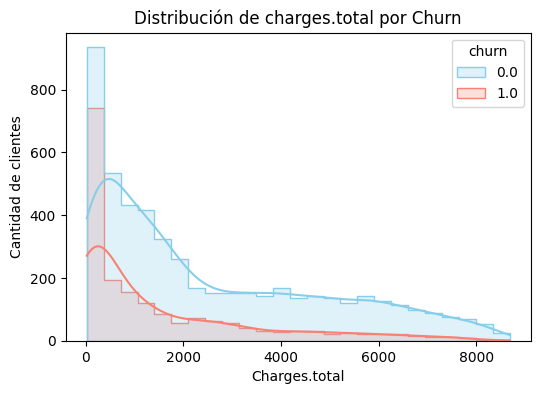

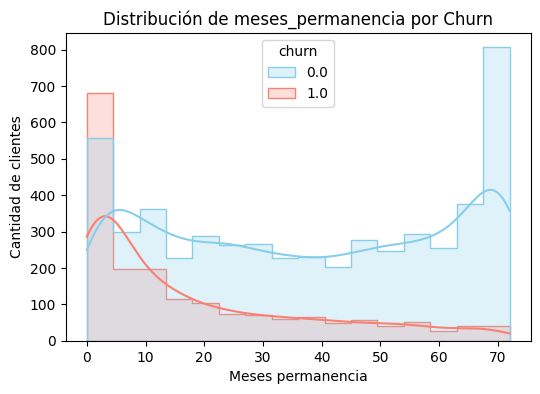

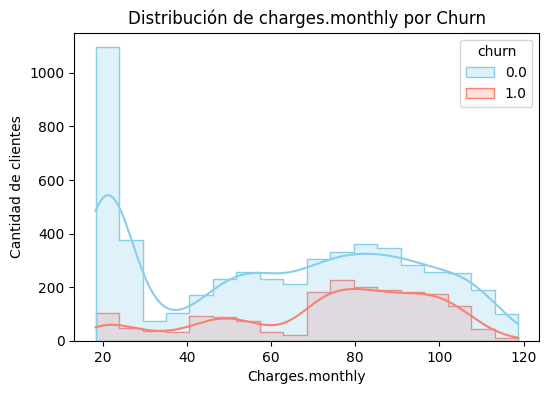

In [60]:
import seaborn as sns

for col in numericas:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df_final, x=col, hue='churn', kde=True, element='step', palette=['skyblue', 'salmon'])
    plt.title(f'Distribución de {col} por Churn')
    plt.xlabel(col.replace('_', ' ').capitalize())
    plt.ylabel('Cantidad de clientes')
    plt.show()


## **Informe final**

**Introducción**

El objetivo de este análisis fue comprender los factores que influyen en la evasión de clientes (Churn) en TelecomX LATAM, con el fin de proponer acciones para reducir la tasa de cancelaciones. El problema de Churn representa una pérdida significativa de ingresos y una amenaza para la fidelidad de la base de clientes. Mediante la exploración de datos, se buscó identificar patrones y variables clave asociadas a la retención o abandono.

**Limpieza y Tratamiento de Datos**

Se realizaron los siguientes pasos:

* Importación de datos desde un archivo JSON, con desanidamiento de estructuras para obtener tablas separadas de información de cliente, teléfono, internet y cuenta.

* Unificación de todas las tablas en un único DataFrame (df_final).

* Revisión de tipos de datos y conversión a formatos adecuados (numérico, fecha, categórico).

* Tratamiento de valores nulos mediante imputación o eliminación según la relevancia de la variable.

**Análisis Exploratorio de Datos**

* Distribución de Churn: Se identificó el porcentaje de clientes que abandonaron el servicio vs. los que permanecieron.

* Variables demográficas: La edad, el tipo de contrato y el tiempo como cliente mostraron relación con el Churn.

* Servicios contratados: Clientes sin servicios de internet o con servicio DSL presentaron menor retención que los de fibra óptica.

* Facturación y cargos mensuales: Los clientes con cargos más altos tendieron a cancelar con mayor frecuencia.

* Visualizaciones: Se generaron histogramas, gráficos de barras y diagramas comparativos que permitieron evidenciar diferencias claras entre grupos con y sin Churn.

**Conclusiones**  

* Los contratos mensuales están fuertemente asociados a mayores tasas de Churn frente a contratos anuales o bianuales.

* Los clientes con mayor gasto mensual presentan una probabilidad superior de cancelar, posiblemente por percepción de alto costo.

* El tipo de servicio de internet influye en la retención: la fibra óptica retiene más que DSL o ausencia de internet.

* La antigüedad del cliente es clave: usuarios nuevos son más propensos a abandonar.

**Recomendaciones**

* Incentivar el cambio de contratos mensuales a planes de mayor duración con beneficios exclusivos.

* Implementar descuentos o paquetes personalizados para clientes con facturación elevada.

* Mejorar la calidad del servicio DSL o incentivar la migración a fibra óptica.

* Desarrollar programas de bienvenida y fidelización para clientes nuevos, reduciendo el riesgo de cancelación en los primeros meses.

* Aplicar modelos predictivos de Churn para anticipar y actuar proactivamente sobre clientes en riesgo.